In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
df=pd.read_csv('/kaggle/input/placement-csv/placement.csv')

In [6]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'LPA')

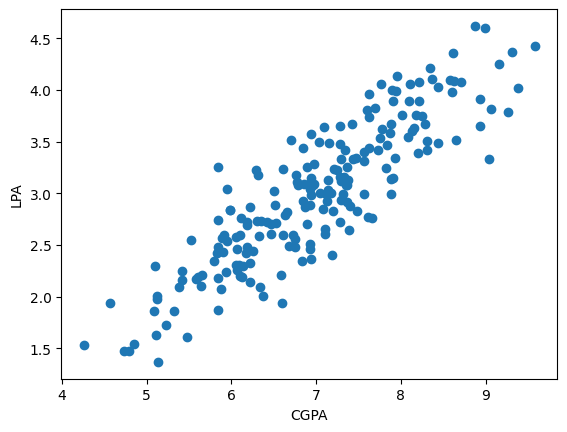

In [7]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('LPA')

In [8]:
x= df.iloc[:,0:1]
y= df.iloc[:,-1]

In [10]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
lr=LinearRegression()

In [14]:
lr.fit(x_train,y_train)

LinearRegression()

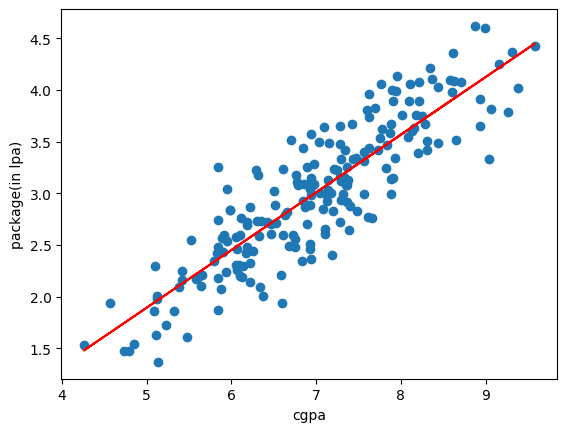

In [15]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(x_train,lr.predict(x_train),color='red')
plt.xlabel('cgpa')
plt.ylabel('package(in lpa)')
plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [17]:
y_pred=lr.predict(x_test)

In [18]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [24]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2_SCORE",r2_score(y_test,y_pred))
r2=r2_score(y_test,y_pred)

MAE 0.2884710931878175
MSE 0.12129235313495532
RMSE 0.3482705171773162
R2_SCORE 0.780730147510384


In [25]:
x_test.shape

(40, 1)

In [26]:
adjusted_r2=1-((1-r2)*(40-1)/(40-1-1))

In [27]:
adjusted_r2

0.7749598882343415

In [28]:
new_df1=df.copy()
new_df1['random_feature']=np.random.random(200)

new_df1=new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.234190,3.26
1,5.12,0.943452,1.98
2,7.82,0.240990,3.25
3,7.42,0.908327,3.67
4,6.94,0.822826,3.57


Text(0, 0.5, 'LPA')

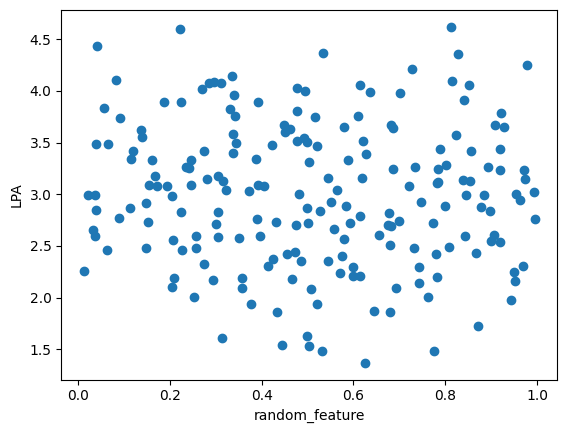

In [30]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('LPA')

In [32]:
x= new_df1.iloc[:,0:2]
y= new_df1.iloc[:,-1]

In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [34]:
lr=LinearRegression()

In [35]:
lr.fit(x_train,y_train)

LinearRegression()

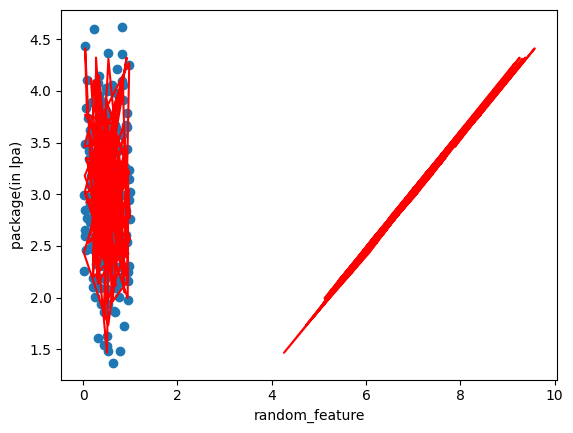

In [37]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.plot(x_train,lr.predict(x_train),color='red')
plt.xlabel('random_feature')
plt.ylabel('package(in lpa)')
plt.show()

In [38]:
y_pred=lr.predict(x_test)

In [39]:
print("R2_SCORE",r2_score(y_test,y_pred))

R2_SCORE 0.7832897690433192


In [40]:
r2=r2_score(y_test,y_pred)
adjusted_r2=1-((1-r2)*(40-1)/(40-1-1))

In [41]:
adjusted_r2

0.7775868682286696